# COVID-19 X-Ray Image Classification

This notebook builds a Convolutional Neural Network (CNN) to classify chest X-ray images into three categories:
- **Covid** - COVID-19 positive cases
- **Normal** - Healthy patients
- **Viral Pneumonia** - Other viral pneumonia cases

## Workflow Overview
1. Download and explore the dataset
2. Convert images to grayscale and save locally
3. Create PyTorch data pipeline with stratified splits
4. Build and train a CNN model
5. Evaluate on test set

In [45]:
print("Test")

Test


In [46]:
import kagglehub

In [47]:
# Download latest version
path = kagglehub.dataset_download("pranavraikokte/covid19-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\matej\.cache\kagglehub\datasets\pranavraikokte\covid19-image-dataset\versions\2


## 1. Exploratory Data Analysis (EDA)

Let's load the dataset and understand its structure - image dimensions, class distribution, and color channels.

In [48]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")

# Path from kagglehub download
dataset_root = Path(path)

# Find all images in the dataset
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
image_data = []

for root, dirs, files in os.walk(dataset_root):
    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            file_path = Path(root) / file
            # Parent folder name = class label
            label = file_path.parent.name
            image_data.append({
                'path': str(file_path),
                'label': label,
                'filename': file
            })

df = pd.DataFrame(image_data)
print(f"Found {len(df)} images")
print("\nClass distribution:")
print(df['label'].value_counts())

Found 317 images

Class distribution:
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64


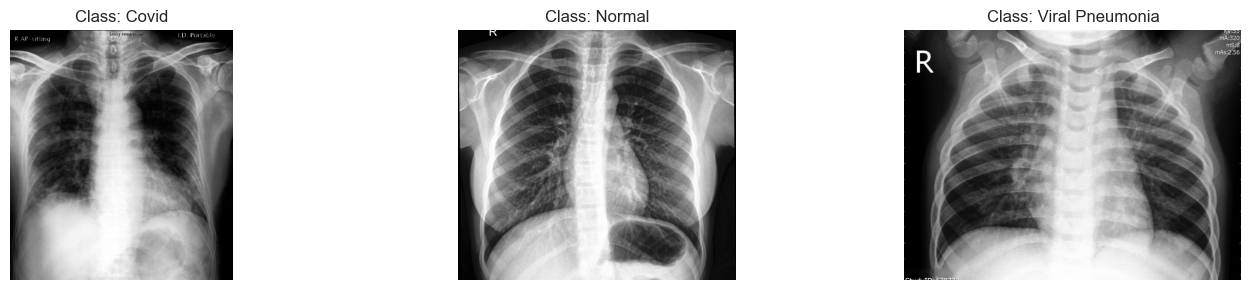

In [49]:
# Display one sample image from each class
unique_labels = df['label'].unique()
num_classes = len(unique_labels)

cols = min(5, num_classes)
rows = (num_classes + cols - 1) // cols

plt.figure(figsize=(15, 3 * rows))
for i, label in enumerate(unique_labels):
    if not df[df['label'] == label].empty:
        sample_row = df[df['label'] == label].sample(1).iloc[0]
        img_path = sample_row['path']
        
        try:
            with Image.open(img_path) as img:
                plt.subplot(rows, cols, i + 1)
                plt.imshow(img)
                plt.title(f"Class: {label}")
                plt.axis('off')
        except Exception as e:
            print(f"Error loading image for class {label}: {e}")

plt.tight_layout()
plt.show()

Average dimensions: 1625 x 1353
Min: 416x341, Max: 4248x4095


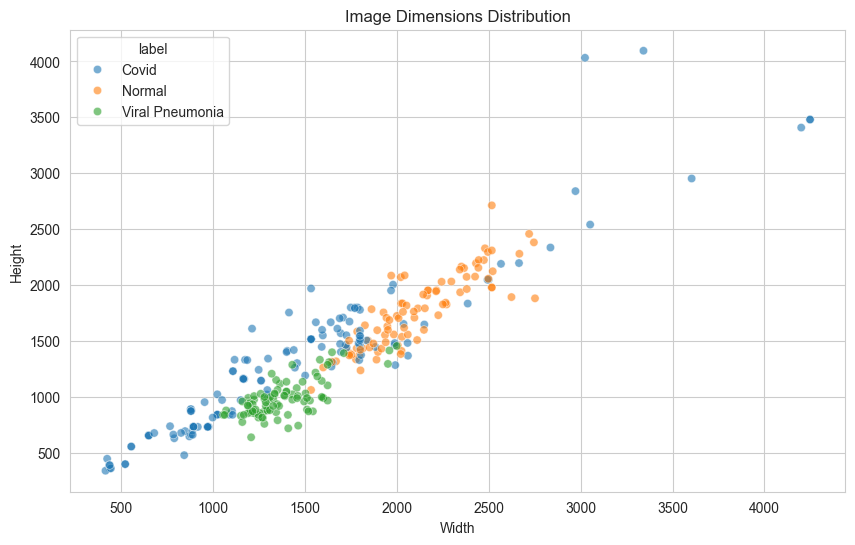

In [50]:
# Analyze image dimensions
widths = []
heights = []

for img_path in df['path']:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        pass

df['width'] = widths
df['height'] = heights

print(f"Average dimensions: {np.mean(widths):.0f} x {np.mean(heights):.0f}")
print(f"Min: {np.min(widths)}x{np.min(heights)}, Max: {np.max(widths)}x{np.max(heights)}")

# Plot dimension distribution by class
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='width', y='height', hue='label', alpha=0.6)
plt.title("Image Dimensions Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

Images per class:
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64


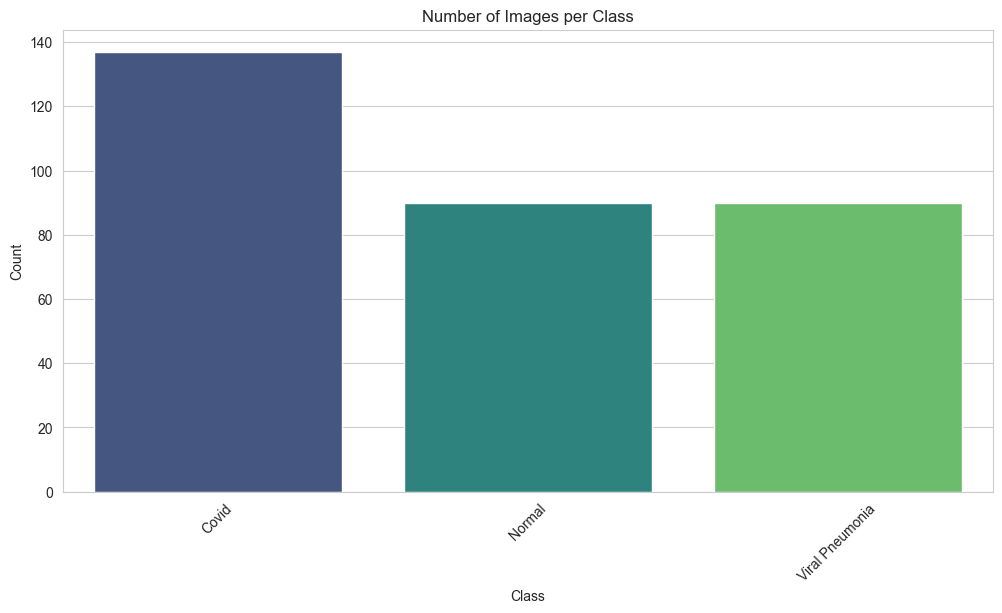

In [51]:
# Visualize class imbalance
class_counts = df['label'].value_counts()
print("Images per class:")
print(class_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, legend=False, palette='viridis')
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Color modes found:
mode
RGB     267
L        42
RGBA      8
Name: count, dtype: int64


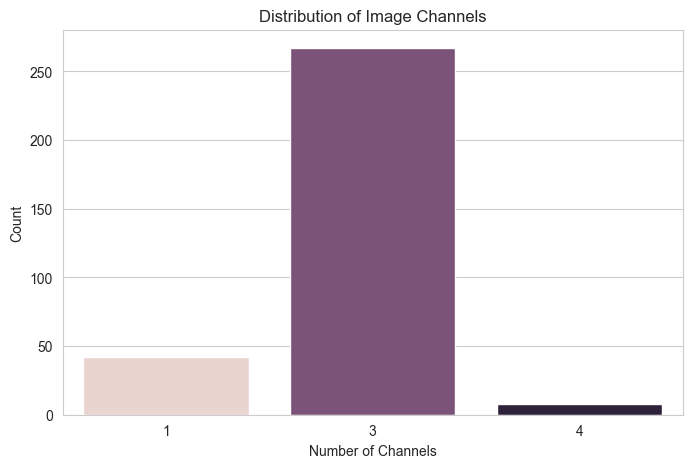

In [52]:
# Check color channels (RGB vs Grayscale)
modes = []
channels = []

for img_path in df['path']:
    try:
        with Image.open(img_path) as img:
            modes.append(img.mode)
            channels.append(len(img.getbands()))
    except:
        modes.append('Error')
        channels.append(0)

df['mode'] = modes
df['channels'] = channels

print("Color modes found:")
print(df['mode'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='channels', hue='channels', legend=False)
plt.title("Distribution of Image Channels")
plt.xlabel("Number of Channels")
plt.ylabel("Count")
plt.show()

## 2. Data Preprocessing

We convert all images to grayscale and save them locally. This standardizes the input and reduces complexity.

In [53]:
import shutil
from tqdm.notebook import tqdm

output_dir = Path('data')

# Clean and recreate output directory
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True)

print(f"Saving grayscale images to: {output_dir.absolute()}")

# Convert each image to grayscale and save
unique_labels = df['label'].unique()

for label in unique_labels:
    class_dir = output_dir / label
    class_dir.mkdir(exist_ok=True)
    
    class_images = df[df['label'] == label]
    print(f"Processing: {label}")
    
    for i, (_, row) in enumerate(tqdm(class_images.iterrows(), total=len(class_images), desc=label)):
        try:
            with Image.open(row['path']) as img:
                gray_img = img.convert('L')  # Convert to grayscale
                new_filename = f"{label}_{i+1:04d}.png"
                gray_img.save(class_dir / new_filename)
        except Exception as e:
            print(f"Error: {row['path']}: {e}")

print("\nConversion complete!")

# Verify the new dataset
new_image_data = []
for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith('.png'):
            file_path = Path(root) / file
            label = file_path.parent.name
            new_image_data.append({'path': str(file_path), 'label': label, 'filename': file})

new_df = pd.DataFrame(new_image_data)
print(f"Created {len(new_df)} grayscale images")
print(new_df['label'].value_counts())

Saving grayscale images to: C:\Users\matej\Nextcloud\FIIT\Semester 5\IAU\covid_dataset\data
Processing: Covid


Covid:   0%|          | 0/137 [00:00<?, ?it/s]

Processing: Normal


Normal:   0%|          | 0/90 [00:00<?, ?it/s]

Processing: Viral Pneumonia


Viral Pneumonia:   0%|          | 0/90 [00:00<?, ?it/s]


Conversion complete!
Created 317 grayscale images
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64


In [54]:
# Verify all images are now single-channel grayscale
grayscale_image_data = []
output_dir = Path('data')

for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith('.png'):
            file_path = Path(root) / file
            label = file_path.parent.name
            grayscale_image_data.append({'path': str(file_path), 'label': label, 'filename': file})

df_grayscale = pd.DataFrame(grayscale_image_data)

# Check channels
modes = []
channels = []
for img_path in tqdm(df_grayscale['path'], desc="Verifying"):
    try:
        with Image.open(img_path) as img:
            modes.append(img.mode)
            channels.append(len(img.getbands()))
    except:
        modes.append('Error')
        channels.append(0)

df_grayscale['mode'] = modes
df_grayscale['channels'] = channels

print("Grayscale dataset verification:")
print(df_grayscale['mode'].value_counts())

Verifying:   0%|          | 0/317 [00:00<?, ?it/s]

Grayscale dataset verification:
mode
L    317
Name: count, dtype: int64


## 3. PyTorch Data Pipeline

We set up the data loading pipeline:
1. Load images with basic transforms
2. Split into train/val/test (70/20/10) with stratification
3. Calculate normalization statistics from training data only
4. Apply normalization and create DataLoaders

In [55]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter

# Hyperparameters
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 32
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

# Basic transforms (no normalization yet - we need to calculate stats first)
basic_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
])

# Load dataset using ImageFolder (expects: data/class_name/image.png)
dataset = datasets.ImageFolder(root='data', transform=basic_transforms)

print(f"Classes: {dataset.classes}")
print(f"Total images: {len(dataset)}")

# Stratified split to maintain class distribution
targets = np.array(dataset.targets)

# First split: train vs (val + test)
train_indices, temp_indices = train_test_split(
    np.arange(len(targets)),
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=targets,
    random_state=42
)

# Second split: val vs test
temp_targets = targets[temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
    stratify=temp_targets,
    random_state=42
)

# Create subsets
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_dataset)} ({len(train_dataset)/len(dataset)*100:.1f}%)")
print(f"  Val:   {len(val_dataset)} ({len(val_dataset)/len(dataset)*100:.1f}%)")
print(f"  Test:  {len(test_dataset)} ({len(test_dataset)/len(dataset)*100:.1f}%)")

Classes: ['Covid', 'Normal', 'Viral Pneumonia']
Total images: 317

Split sizes:
  Train: 221 (69.7%)
  Val:   64 (20.2%)
  Test:  32 (10.1%)


In [56]:
# Calculate mean and std from training data only (prevents data leakage)
def calculate_mean_std(loader):
    """Calculate channel-wise mean and std."""
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in tqdm(loader, desc="Calculating stats"):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data ** 2, dim=[0, 2, 3])
        num_batches += 1
    
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5
    return mean, std

train_loader_for_stats = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
MEAN, STD = calculate_mean_std(train_loader_for_stats)

print(f"Normalization stats (from training data):")
print(f"  Mean: {MEAN.item():.4f}")
print(f"  Std:  {STD.item():.4f}")

Calculating stats:   0%|          | 0/7 [00:00<?, ?it/s]

Normalization stats (from training data):
  Mean: 0.4962
  Std:  0.2807


In [57]:
# Apply normalization and create final DataLoaders
final_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Update dataset transforms (affects all subsets)
dataset.transform = final_transforms

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify normalization
sample_batch, _ = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Batch mean: {sample_batch.mean():.4f} (should be ~0)")
print(f"Batch std:  {sample_batch.std():.4f} (should be ~1)")

Batch shape: torch.Size([32, 1, 300, 300])
Batch mean: 0.0310 (should be ~0)
Batch std:  0.9991 (should be ~1)


In [58]:
# Class mapping summary
NUM_CLASSES = len(dataset.classes)

print("Class Mapping:")
for class_name, class_idx in dataset.class_to_idx.items():
    print(f"  {class_idx} -> {class_name}")
print(f"\nNumber of classes: {NUM_CLASSES}")

Class Mapping:
  0 -> Covid
  1 -> Normal
  2 -> Viral Pneumonia

Number of classes: 3


## 4. CNN Model Architecture

A simple CNN with 3 convolutional blocks followed by fully connected layers:
- Conv blocks: Conv2D → BatchNorm → ReLU → MaxPool
- FC layers: Linear → ReLU → Dropout → Linear (output)

In [59]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        # Conv Block 1: 1 -> 32 channels, 300x300 -> 150x150
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Conv Block 2: 32 -> 64 channels, 150x150 -> 75x75
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Conv Block 3: 64 -> 128 channels, 75x75 -> 37x37
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Adaptive pooling ensures fixed output size (128 x 4 x 4)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv blocks with ReLU activation
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten and FC layers
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # Raw logits (no softmax - CrossEntropyLoss handles it)
        
        return x

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(model)

Using device: cpu
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=3, bi

## 5. Training Functions

Helper functions for training, evaluation, and visualization.

In [60]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics."""
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch and return metrics."""
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': loss.item()})
    
    metrics = calculate_metrics(all_targets, all_preds)
    metrics['loss'] = running_loss / len(loader.dataset)
    return metrics

def evaluate_model(model, loader, criterion, device, desc="Validation"):
    """Evaluate model and return metrics with predictions."""
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    
    metrics = calculate_metrics(all_targets, all_preds)
    metrics['loss'] = running_loss / len(loader.dataset)
    metrics['targets'] = all_targets
    metrics['predictions'] = all_preds
    return metrics

In [61]:
def plot_training_history(history, best_val_cm_data=None, classes=None):
    """Plot training curves and confusion matrix."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    def plot_metric(ax, train_key, val_key, title, ylabel):
        ax.plot(epochs, history[train_key], label='Train', marker='o', markersize=3)
        ax.plot(epochs, history[val_key], label='Val', marker='s', markersize=3)
        ax.set_title(title)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)
    
    plot_metric(axes[0, 0], 'train_loss', 'val_loss', 'Loss', 'Loss')
    plot_metric(axes[0, 1], 'train_accuracy', 'val_accuracy', 'Accuracy', 'Accuracy')
    plot_metric(axes[0, 2], 'train_f1', 'val_f1', 'F1 Score', 'F1')
    plot_metric(axes[1, 0], 'train_precision', 'val_precision', 'Precision', 'Precision')
    plot_metric(axes[1, 1], 'train_recall', 'val_recall', 'Recall', 'Recall')
    
    # Confusion matrix
    if best_val_cm_data is not None and classes is not None:
        y_true, y_pred = best_val_cm_data
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=classes, yticklabels=classes, ax=axes[1, 2])
        axes[1, 2].set_title('Best Val Confusion Matrix')
        axes[1, 2].set_ylabel('True')
        axes[1, 2].set_xlabel('Predicted')
    else:
        axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    """Plot standalone confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

def plot_metrics_barplot(metrics_dict, title="Metrics"):
    """Plot metrics as bar chart."""
    metrics_to_plot = {k: v for k, v in metrics_dict.items() if k not in ['targets', 'predictions']}
    df = pd.DataFrame({'Metric': list(metrics_to_plot.keys()), 'Score': list(metrics_to_plot.values())})
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Metric', y='Score', data=df, hue='Metric', palette='viridis', legend=False)
    plt.title(title)
    plt.ylim(0, max(1.1, df['Score'].max() + 0.1))
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    plt.show()

## 6. Training Loop

Train the model with early stopping based on validation performance.

Training with early stopping (metric: accuracy, patience: 15)

Epoch 1/50


Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train - Loss: 1.1389, Acc: 0.4570, F1: 0.4583
Val   - Loss: 0.8129, Acc: 0.7344, F1: 0.6887
  -> New best accuracy: 0.7344. Model saved.

Epoch 2/50


Training:   0%|          | 0/7 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train - Loss: 0.0691, Acc: 0.9774, F1: 0.9775
Val   - Loss: 0.3744, Acc: 0.8750, F1: 0.8662
  -> No improvement for 14 epoch(s).

Epoch 26/50


Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train - Loss: 0.1491, Acc: 0.9502, F1: 0.9500
Val   - Loss: 0.4330, Acc: 0.8281, F1: 0.8154
  -> No improvement for 15 epoch(s).
Early stopping triggered!

Training complete!


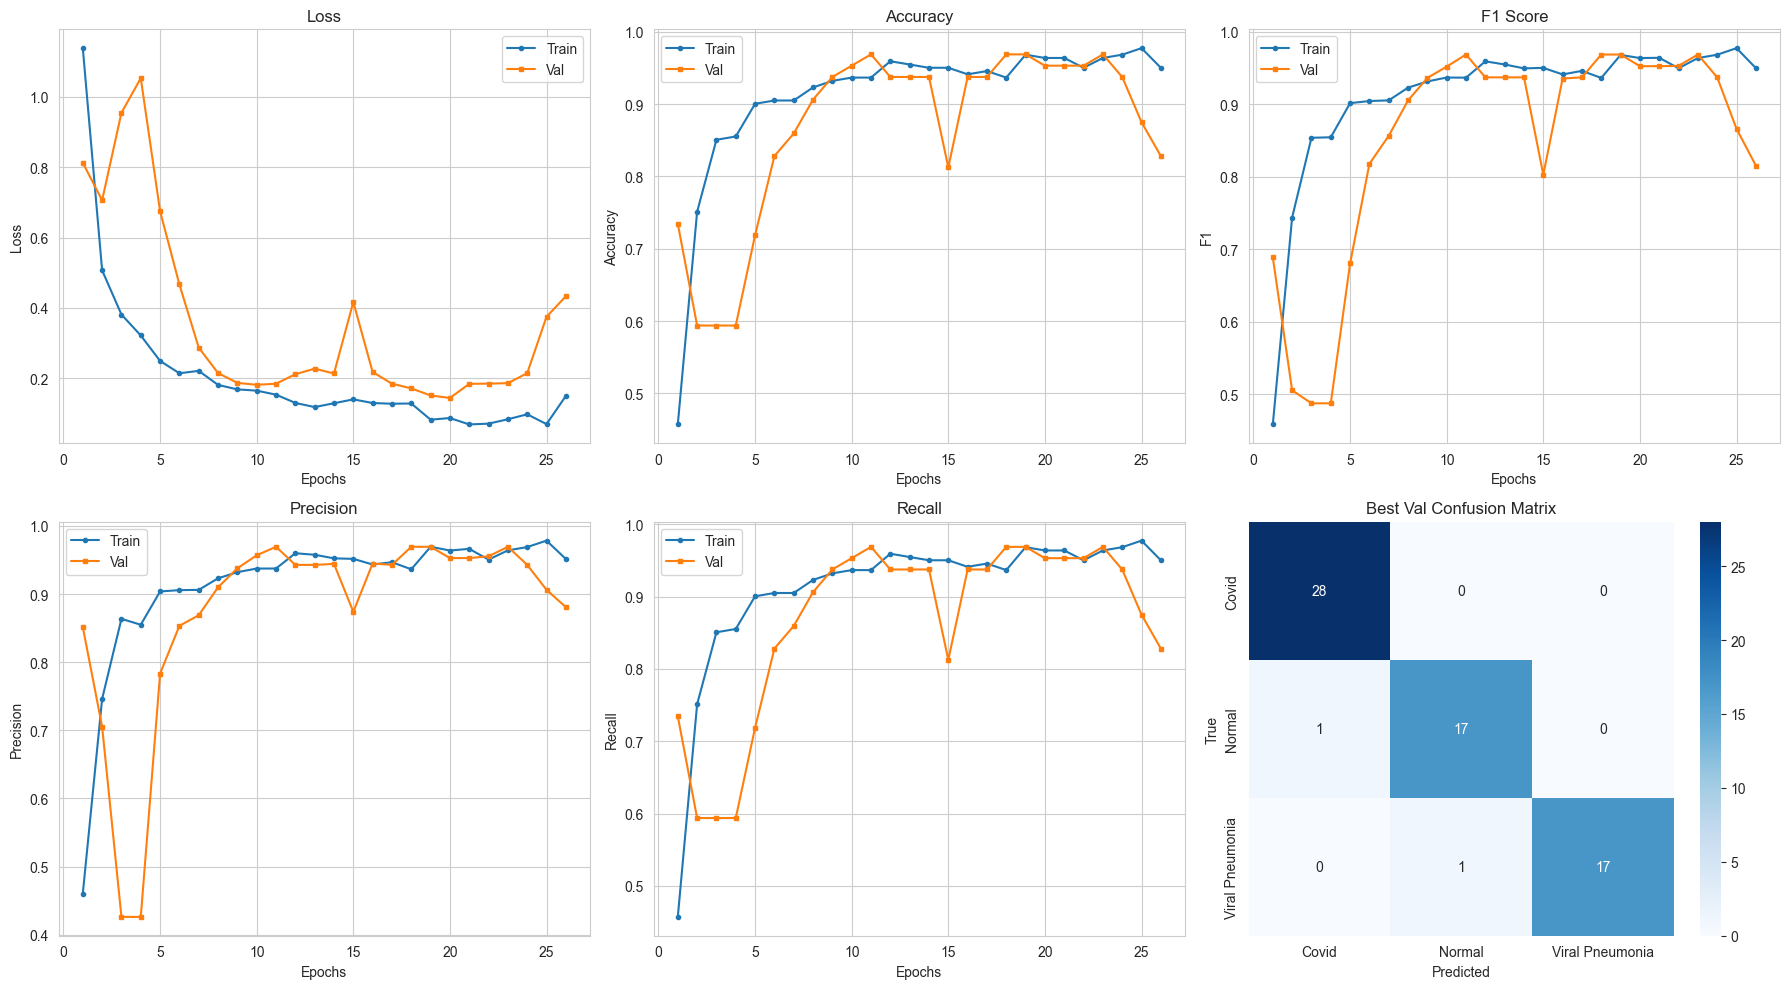

In [62]:
import copy
import torch.optim as optim

# Training hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
PATIENCE = 15
EARLY_STOP_METRIC = 'accuracy'  # Options: 'loss', 'accuracy', 'f1', 'precision', 'recall'

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Track training history
history = {
    'train_loss': [], 'train_accuracy': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

# Early stopping setup
best_metric_value = float('inf') if EARLY_STOP_METRIC == 'loss' else float('-inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())
best_val_cm_data = None

def is_better(current, best, metric_name):
    """Check if current metric is better (lower for loss, higher for others)."""
    return current < best if metric_name == 'loss' else current > best

print(f"Training with early stopping (metric: {EARLY_STOP_METRIC}, patience: {PATIENCE})")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate_model(model, val_loader, criterion, device)
    
    # Store metrics
    for key in ['loss', 'accuracy', 'precision', 'recall', 'f1']:
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])
    
    print(f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, F1: {train_metrics['f1']:.4f}")
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, F1: {val_metrics['f1']:.4f}")
    
    # Early stopping check
    current_metric = val_metrics[EARLY_STOP_METRIC]
    
    if is_better(current_metric, best_metric_value, EARLY_STOP_METRIC):
        best_metric_value = current_metric
        best_model_wts = copy.deepcopy(model.state_dict())
        best_val_cm_data = (val_metrics['targets'], val_metrics['predictions'])
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> New best {EARLY_STOP_METRIC}: {current_metric:.4f}. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered!")
            break

print("\nTraining complete!")
model.load_state_dict(best_model_wts)
plot_training_history(history, best_val_cm_data, dataset.classes)

## 7. Evaluation on Test Set

Load the best model and evaluate on the held-out test set.

Testing:   0%|          | 0/1 [00:00<?, ?it/s]

TEST SET RESULTS
   Metric    Score
     Loss 0.067618
 Accuracy 1.000000
Precision 1.000000
   Recall 1.000000
 F1 Score 1.000000


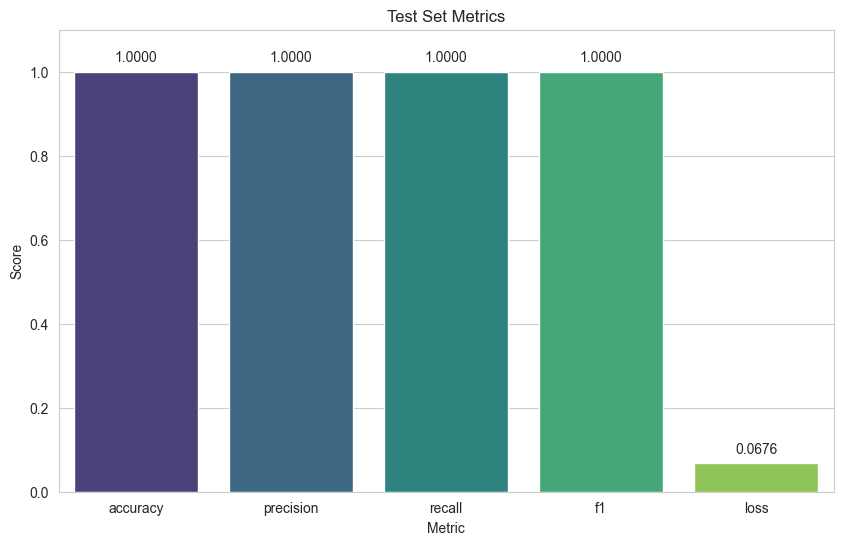

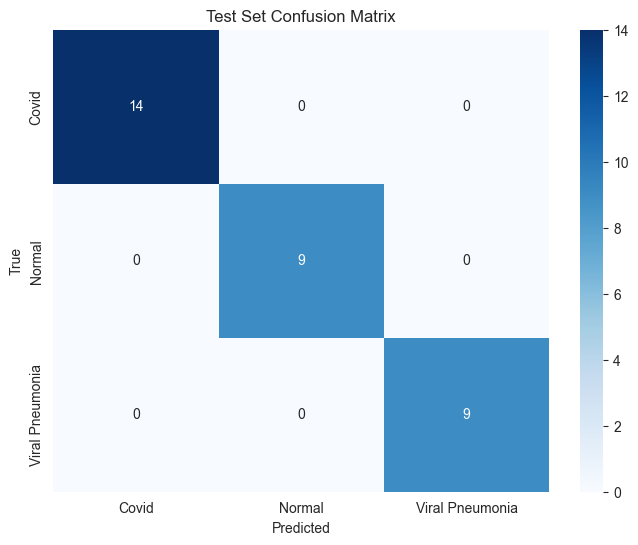

In [63]:
# Load best model from disk and evaluate on test set
loaded_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
loaded_model.load_state_dict(torch.load('best_model.pth'))
loaded_model.eval()

test_metrics = evaluate_model(loaded_model, test_loader, criterion, device, desc="Testing")

# Display results
results_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [test_metrics['loss'], test_metrics['accuracy'], 
              test_metrics['precision'], test_metrics['recall'], test_metrics['f1']]
})

print("="*50)
print("TEST SET RESULTS")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

plot_metrics_barplot(test_metrics, title="Test Set Metrics")
plot_confusion_matrix(test_metrics['targets'], test_metrics['predictions'], 
                      dataset.classes, title="Test Set Confusion Matrix")

In [65]:
# Verify saved model matches in-memory model
verify_metrics = evaluate_model(model, test_loader, criterion, device, desc="Verification")

comparison_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1'],
    'In-Memory': [verify_metrics['loss'], verify_metrics['accuracy'], 
                  verify_metrics['precision'], verify_metrics['recall'], verify_metrics['f1']],
    'Loaded': [test_metrics['loss'], test_metrics['accuracy'], 
               test_metrics['precision'], test_metrics['recall'], test_metrics['f1']]
})
comparison_df['Match'] = np.isclose(comparison_df['In-Memory'], comparison_df['Loaded'])

print("Model save/load verification:")
print(comparison_df.to_string(index=False))
print("\nAll metrics match!" if comparison_df['Match'].all() else "\nMismatch detected!")

Verification:   0%|          | 0/1 [00:00<?, ?it/s]

Model save/load verification:
   Metric  In-Memory   Loaded  Match
     Loss   0.067618 0.067618   True
 Accuracy   1.000000 1.000000   True
Precision   1.000000 1.000000   True
   Recall   1.000000 1.000000   True
       F1   1.000000 1.000000   True

All metrics match!
